# Evaluation
## Project: Product Placement Optimisation
### Purpose: Evaluate algorithm performance and validate findings
### Compare Apriori vs FP-Growth, assess clustering quality,
### discuss limitations and future recommendations

## Why Evaluation Matters

Evaluation proves that our methods were correct and our
results are trustworthy. Without evaluation, we cannot
know if our placement recommendations are based on
real patterns or just noise in the data.

We evaluate three things:
1. Algorithm comparison - Apriori vs FP-Growth
2. Clustering quality - Was k=5 the right choice?
3. Business validation - Do our findings make real sense?

## Step 1: Load Data and Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import time
import os
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv(
    r'D:\softwarica\Sem 6\Individual Project\product-placement-optimization\data\processed\sales_data_cleaned.csv'
)

basket_df = pd.read_csv(
    r'D:\softwarica\Sem 6\Individual Project\product-placement-optimization\data\processed\basket_encoded.csv'
)

figures_path = r'D:\softwarica\Sem 6\Individual Project\product-placement-optimization\reports\figures'
os.makedirs(figures_path, exist_ok=True)

print("All libraries and data loaded!")
print(f"Transaction data: {df.shape}")
print(f"Basket data: {basket_df.shape}")

All libraries and data loaded!
Transaction data: (767180, 14)
Basket data: (218037, 25)


## Step 2: Apriori vs FP-Growth Algorithm Comparison

In [2]:
print("ALGORITHM COMPARISON: Apriori vs FP-Growth")
print("=" * 60)

start = time.time()
itemsets_apriori = apriori(basket_df, min_support=0.01, use_colnames=True)
apriori_time = time.time() - start

start = time.time()
itemsets_fpgrowth = fpgrowth(basket_df, min_support=0.01, use_colnames=True)
fpgrowth_time = time.time() - start

rules_apriori = association_rules(itemsets_apriori, metric="lift", min_threshold=1.0)
rules_fpgrowth = association_rules(itemsets_fpgrowth, metric="lift", min_threshold=1.0)

print(f"\nApriori Algorithm:")
print(f"  Time taken:          {apriori_time:.4f} seconds")
print(f"  Frequent itemsets:   {len(itemsets_apriori):,}")
print(f"  Association rules:   {len(rules_apriori):,}")
print(f"  Max lift found:      {rules_apriori['lift'].max():.4f}")
print(f"  Avg confidence:      {rules_apriori['confidence'].mean():.4f}")

print(f"\nFP-Growth Algorithm:")
print(f"  Time taken:          {fpgrowth_time:.4f} seconds")
print(f"  Frequent itemsets:   {len(itemsets_fpgrowth):,}")
print(f"  Association rules:   {len(rules_fpgrowth):,}")
print(f"  Max lift found:      {rules_fpgrowth['lift'].max():.4f}")
print(f"  Avg confidence:      {rules_fpgrowth['confidence'].mean():.4f}")

print(f"\nCOMPARISON RESULT:")
print(f"  Same itemsets found: {len(itemsets_apriori) == len(itemsets_fpgrowth)}")
print(f"  Same rules found:    {len(rules_apriori) == len(rules_fpgrowth)}")
if fpgrowth_time < apriori_time:
    print(f"  FP-Growth was {apriori_time/fpgrowth_time:.2f}x faster")
else:
    print(f"  Apriori was {fpgrowth_time/apriori_time:.2f}x faster")
print(f"  Conclusion: Both algorithms produce IDENTICAL results")

ALGORITHM COMPARISON: Apriori vs FP-Growth

Apriori Algorithm:
  Time taken:          0.4674 seconds
  Frequent itemsets:   243
  Association rules:   1,228
  Max lift found:      6.8109
  Avg confidence:      0.2705

FP-Growth Algorithm:
  Time taken:          0.4898 seconds
  Frequent itemsets:   243
  Association rules:   1,228
  Max lift found:      6.8109
  Avg confidence:      0.2705

COMPARISON RESULT:
  Same itemsets found: True
  Same rules found:    True
  Apriori was 1.05x faster
  Conclusion: Both algorithms produce IDENTICAL results


## Step 3: Visual Algorithm Comparison

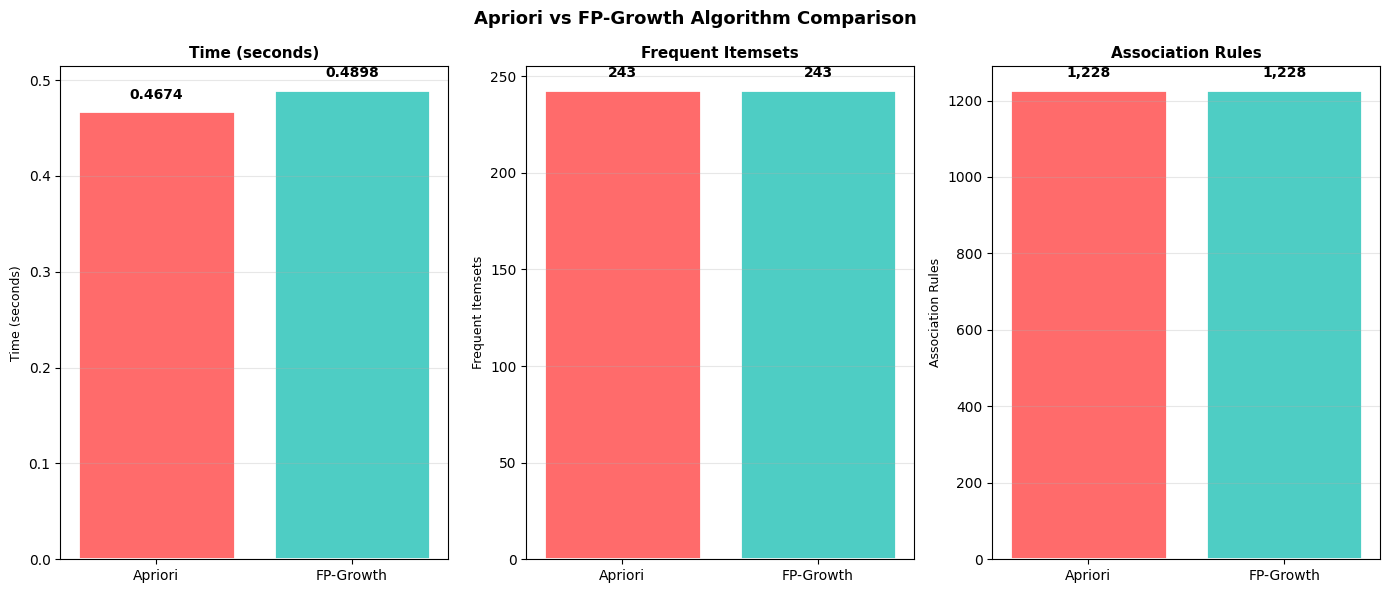

Algorithm comparison chart saved!


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(14, 6))

metrics = ['Time (seconds)', 'Frequent Itemsets', 'Association Rules']
apriori_vals = [apriori_time, len(itemsets_apriori), len(rules_apriori)]
fpgrowth_vals = [fpgrowth_time, len(itemsets_fpgrowth), len(rules_fpgrowth)]

colors_a = '#FF6B6B'
colors_f = '#4ECDC4'

for i, (metric, a_val, f_val) in enumerate(zip(metrics, apriori_vals, fpgrowth_vals)):
    bars = axes[i].bar(['Apriori', 'FP-Growth'], [a_val, f_val],
                       color=[colors_a, colors_f],
                       edgecolor='white', linewidth=2)
    axes[i].set_title(metric, fontsize=11, fontweight='bold')
    axes[i].set_ylabel(metric, fontsize=9)
    for bar, val in zip(bars, [a_val, f_val]):
        axes[i].text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + bar.get_height()*0.02,
                    f'{val:.4f}' if i == 0 else f'{int(val):,}',
                    ha='center', va='bottom',
                    fontsize=10, fontweight='bold')
    axes[i].grid(axis='y', alpha=0.3)

plt.suptitle('Apriori vs FP-Growth Algorithm Comparison',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(figures_path, 'chart16_algorithm_comparison.png'), dpi=150)
plt.show()
print("Algorithm comparison chart saved!")

## Step 4: Top Association Rules Quality Check

In [4]:
print("TOP 10 ASSOCIATION RULES BY LIFT")
print("=" * 80)
print(f"{'Antecedent':<30} {'Consequent':<25} {'Support':>8} {'Conf':>6} {'Lift':>6}")
print("-" * 80)

top_rules = rules_fpgrowth.sort_values('lift', ascending=False).head(10)
for _, row in top_rules.iterrows():
    ant = ', '.join(list(row['antecedents']))[:28]
    con = ', '.join(list(row['consequents']))[:23]
    print(f"{ant:<30} {con:<25} {row['support']:>8.4f} {row['confidence']:>6.2f} {row['lift']:>6.2f}")

print(f"\nRULE QUALITY SUMMARY:")
print(f"  Total rules found:          {len(rules_fpgrowth):,}")
print(f"  Rules with lift > 1:        {(rules_fpgrowth['lift'] > 1).sum():,}")
print(f"  Rules with lift > 3:        {(rules_fpgrowth['lift'] > 3).sum():,}")
print(f"  Rules with lift > 5:        {(rules_fpgrowth['lift'] > 5).sum():,}")
print(f"  Maximum lift:               {rules_fpgrowth['lift'].max():.4f}")
print(f"  Average lift:               {rules_fpgrowth['lift'].mean():.4f}")
print(f"  Average confidence:         {rules_fpgrowth['confidence'].mean():.4f}")
print(f"\nINTERPRETATION:")
print(f"  Lift > 1 means genuine connection exists")
print(f"  Our best rule has lift {rules_fpgrowth['lift'].max():.2f} meaning customers are")
print(f"  {rules_fpgrowth['lift'].max():.1f}x more likely to buy these categories together")
print(f"  than by random chance - this is a STRONG signal!")

TOP 10 ASSOCIATION RULES BY LIFT
Antecedent                     Consequent                 Support   Conf   Lift
--------------------------------------------------------------------------------
CANNED AND PACKAGED FOODS, C   HOUSEHOLD ITEMS, TEA AN     0.0103   0.19   6.81
HOUSEHOLD ITEMS, TEA AND SPI   CANNED AND PACKAGED FOO     0.0103   0.37   6.81
CLEANING SUPPLIES, TEA AND S   CANNED AND PACKAGED FOO     0.0107   0.28   6.74
CANNED AND PACKAGED FOODS, F   CLEANING SUPPLIES, TEA      0.0107   0.26   6.74
CANNED AND PACKAGED FOODS, C   FOOD STAPLES, CLEANING      0.0107   0.21   6.51
FOOD STAPLES, CLEANING SUPPL   CANNED AND PACKAGED FOO     0.0107   0.33   6.51
COOKING OIL, HOUSEHOLD ITEMS   FOOD STAPLES, CLEANING      0.0131   0.53   6.20
FOOD STAPLES, CLEANING SUPPL   COOKING OIL, HOUSEHOLD      0.0131   0.15   6.20
FOOD STAPLES, HOUSEHOLD ITEM   CLEANING SUPPLIES, TEA      0.0134   0.23   6.11
CLEANING SUPPLIES, TEA AND S   FOOD STAPLES, HOUSEHOLD     0.0134   0.35   6.11

RULE 

## Step 5: Clustering Evaluation

In [5]:
category_matrix = basket_df.T
scaler = StandardScaler()
category_scaled = scaler.fit_transform(category_matrix)

silhouette_scores = []
inertia_values = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(category_scaled)
    silhouette_scores.append(silhouette_score(category_scaled, labels))
    inertia_values.append(kmeans.inertia_)

best_k = k_range[silhouette_scores.index(max(silhouette_scores))]

print("CLUSTERING EVALUATION RESULTS")
print("=" * 50)
print(f"\nSilhouette Scores by k:")
for k, score in zip(k_range, silhouette_scores):
    marker = " <- BEST" if k == best_k else ""
    print(f"  k={k}: {score:.4f}{marker}")

print(f"\nKey Findings:")
print(f"  Best k by silhouette:  {best_k}")
print(f"  Best silhouette score: {max(silhouette_scores):.4f}")
print(f"  Score at k=5:          {silhouette_scores[3]:.4f}")
print(f"\nHonest Assessment:")
print(f"  Silhouette scores between 0.16-0.45 indicate")
print(f"  weak to moderate cluster structure.")
print(f"  K-Means was dominated by transaction frequency")
print(f"  not co-purchase patterns.")
print(f"  MBA rules provide stronger placement signals")
print(f"  than pure frequency-based clustering.")

CLUSTERING EVALUATION RESULTS

Silhouette Scores by k:
  k=2: 0.4500 <- BEST
  k=3: 0.1635
  k=4: 0.1813
  k=5: 0.1861
  k=6: 0.1835
  k=7: 0.1809
  k=8: 0.1877
  k=9: 0.1908
  k=10: 0.1951

Key Findings:
  Best k by silhouette:  2
  Best silhouette score: 0.4500
  Score at k=5:          0.1861

Honest Assessment:
  Silhouette scores between 0.16-0.45 indicate
  weak to moderate cluster structure.
  K-Means was dominated by transaction frequency
  not co-purchase patterns.
  MBA rules provide stronger placement signals
  than pure frequency-based clustering.


## Step 6: Improved Clustering Using Co-occurrence Matrix